# 04 — The Jagged Frontier Quantified

Why does occupation-level prediction fail? Because **tasks within the same occupation
have wildly different automation patterns.** This within-occupation heterogeneity — the
"jagged frontier" — directly causes the occupation-level null result.

This notebook quantifies jaggedness and shows how O*NET skill profiles
predict which occupations resist automation.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix, load_onet_skills
from src.features import (
    build_feature_matrix, build_task_analysis_matrix,
    compute_within_occupation_heterogeneity,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
het = compute_within_occupation_heterogeneity(tasks)

print(f"Occupations with heterogeneity data: {len(het)}")
print(f"\nAutonomy range within occupations:")
print(het['autonomy_range'].describe())

Occupations with heterogeneity data: 724

Autonomy range within occupations:
count    724.000000
mean       0.428694
std        0.331372
min        0.000000
25%        0.119093
50%        0.438184
75%        0.664719
max        1.823877
Name: autonomy_range, dtype: float64


## Visualizing within-occupation task heterogeneity

Each occupation contains tasks with very different AI autonomy levels.
This is why averaging to the occupation level destroys signal.

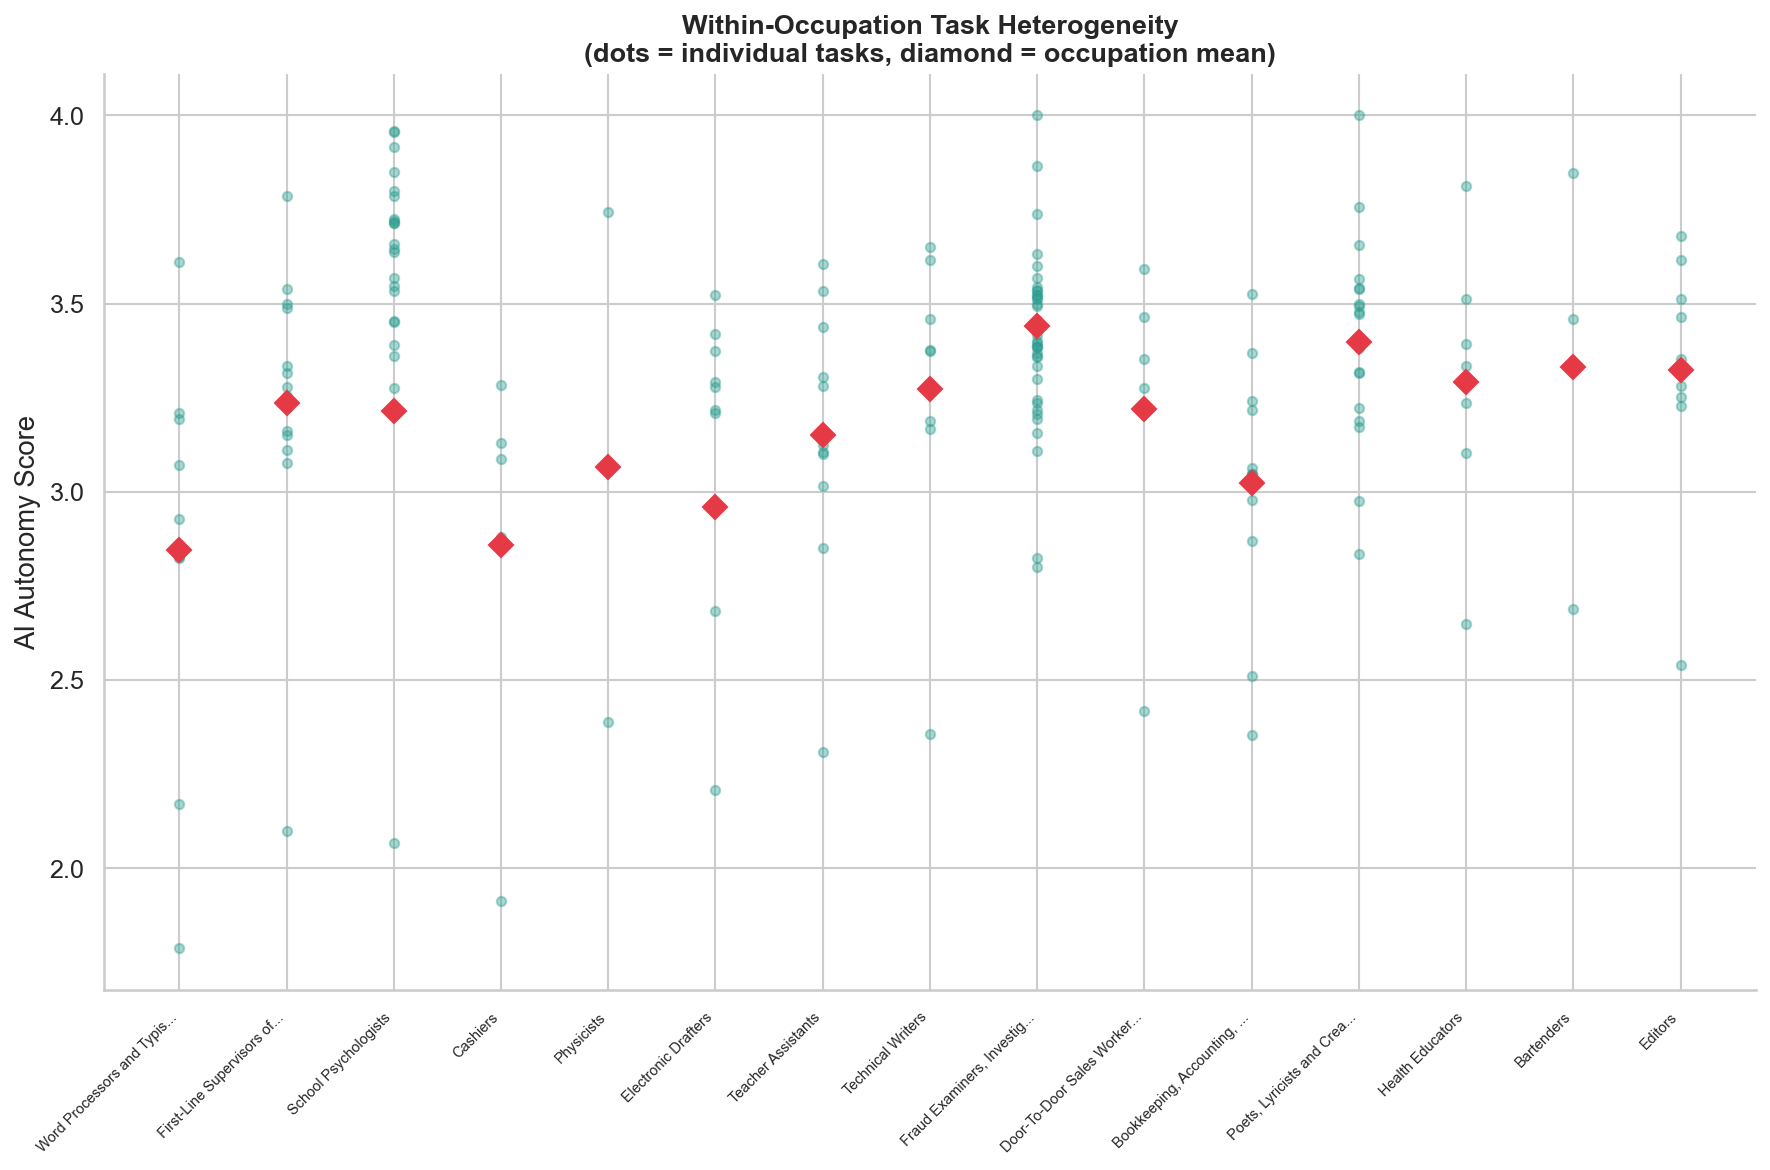

The occupation mean (diamond) hides enormous task-level variation (dots).
This is why occupation-level prediction fails.


In [3]:
# Show the most heterogeneous occupations
top_het = het.nlargest(15, 'autonomy_range').copy()

# Get underlying task data for these occupations
top_socs = set(top_het['soc_code'])
top_tasks = tasks[tasks['soc_code'].isin(top_socs)].copy()

fig, ax = plt.subplots(figsize=(12, 8))

for i, (_, occ) in enumerate(top_het.iterrows()):
    occ_tasks = top_tasks[top_tasks['soc_code'] == occ['soc_code']]['ai_autonomy_mean'].dropna()
    ax.scatter([i] * len(occ_tasks), occ_tasks, alpha=0.4, s=20, color=C['teal'])
    ax.plot([i], [occ['autonomy_mean']], 'D', color=C['auto'], markersize=8, zorder=5)

ax.set_xticks(range(len(top_het)))
labels = [t[:25] + '...' if len(t) > 25 else t for t in top_het['title'].fillna(top_het['soc_code'])]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('AI Autonomy Score')
ax.set_title('Within-Occupation Task Heterogeneity\n(dots = individual tasks, diamond = occupation mean)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/11_within_occupation_heterogeneity.png', bbox_inches='tight')
plt.show()

print(f"The occupation mean (diamond) hides enormous task-level variation (dots).")
print(f"This is why occupation-level prediction fails.")

## Heterogeneity explains the occupation-level null result

Do occupations with more within-occupation variance have less predictable automation trajectories?

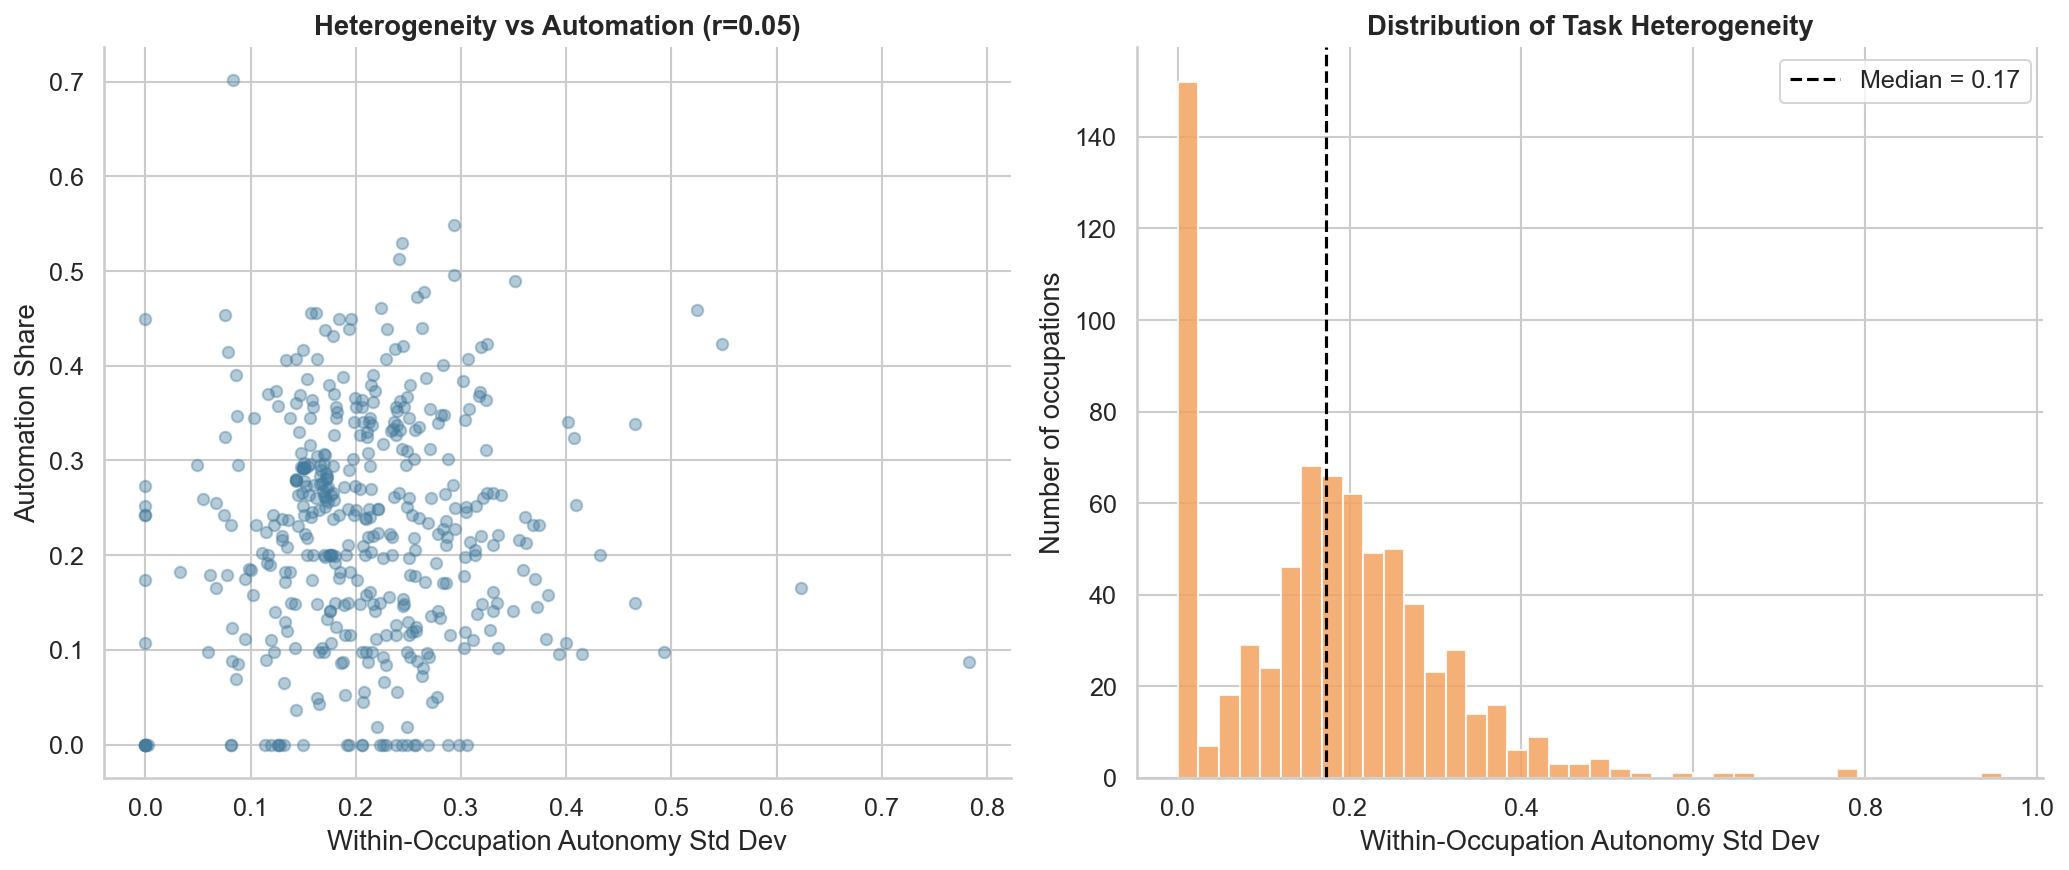

In [4]:
# Merge heterogeneity with occupation-level features
occ_features = build_feature_matrix()
occ_het = occ_features.merge(het[['soc_code', 'autonomy_std', 'autonomy_range', 'n_tasks']],
                              on='soc_code', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: heterogeneity vs automation share
ax = axes[0]
ax.scatter(occ_het['autonomy_std'], occ_het['latest_automation_share'],
           alpha=0.4, s=30, color=C['aug'])
r, p = stats.pearsonr(occ_het['autonomy_std'].dropna(), 
                      occ_het.loc[occ_het['autonomy_std'].notna(), 'latest_automation_share'])
ax.set_xlabel('Within-Occupation Autonomy Std Dev')
ax.set_ylabel('Automation Share')
ax.set_title(f'Heterogeneity vs Automation (r={r:.2f})', fontweight='bold')

# Right: heterogeneity distribution
ax = axes[1]
ax.hist(het['autonomy_std'].dropna(), bins=40, color=C['accent'], alpha=0.85, edgecolor='white')
ax.axvline(het['autonomy_std'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f"Median = {het['autonomy_std'].median():.2f}")
ax.set_xlabel('Within-Occupation Autonomy Std Dev')
ax.set_ylabel('Number of occupations')
ax.set_title('Distribution of Task Heterogeneity', fontweight='bold')
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../figures/12_heterogeneity_analysis.png', bbox_inches='tight')
plt.show()

## O*NET skill profiles and automation resistance

Which skills predict that an occupation will have lower automation?

In [5]:
skills = load_onet_skills()
skill_cols = [c for c in skills.columns if c.startswith('skill_')]

# Merge skills with occupation automation data
occ_skills = occ_features[['soc_code', 'latest_automation_share', 'automation_velocity']].merge(
    skills, on='soc_code', how='inner'
)

print(f"Occupations with skill data: {len(occ_skills)}")
print()
print("Skills most correlated with automation share:")
corrs = []
for col in skill_cols:
    valid = occ_skills[['latest_automation_share', col]].dropna()
    if len(valid) > 30:
        r, p = stats.pearsonr(valid['latest_automation_share'], valid[col])
        corrs.append((col.replace('skill_', ''), r, p))

corrs.sort(key=lambda x: x[1])
print("\n  MOST automation-associated (positive r):")
for name, r, p in corrs[-5:]:
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"    {name:40s} r={r:+.3f} {sig}")
print("\n  LEAST automation-associated (negative r):")
for name, r, p in corrs[:5]:
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"    {name:40s} r={r:+.3f} {sig}")

Occupations with skill data: 274

Skills most correlated with automation share:

  MOST automation-associated (positive r):
    programming                              r=-0.053 
    learning_strategies                      r=-0.046 
    instructing                              r=-0.042 
    service_orientation                      r=-0.041 
    time_management                          r=-0.035 

  LEAST automation-associated (negative r):
    complex_problem_solving                  r=-0.295 ***
    systems_analysis                         r=-0.285 ***
    systems_evaluation                       r=-0.280 ***
    science                                  r=-0.266 ***
    judgment_and_decision_making             r=-0.261 ***


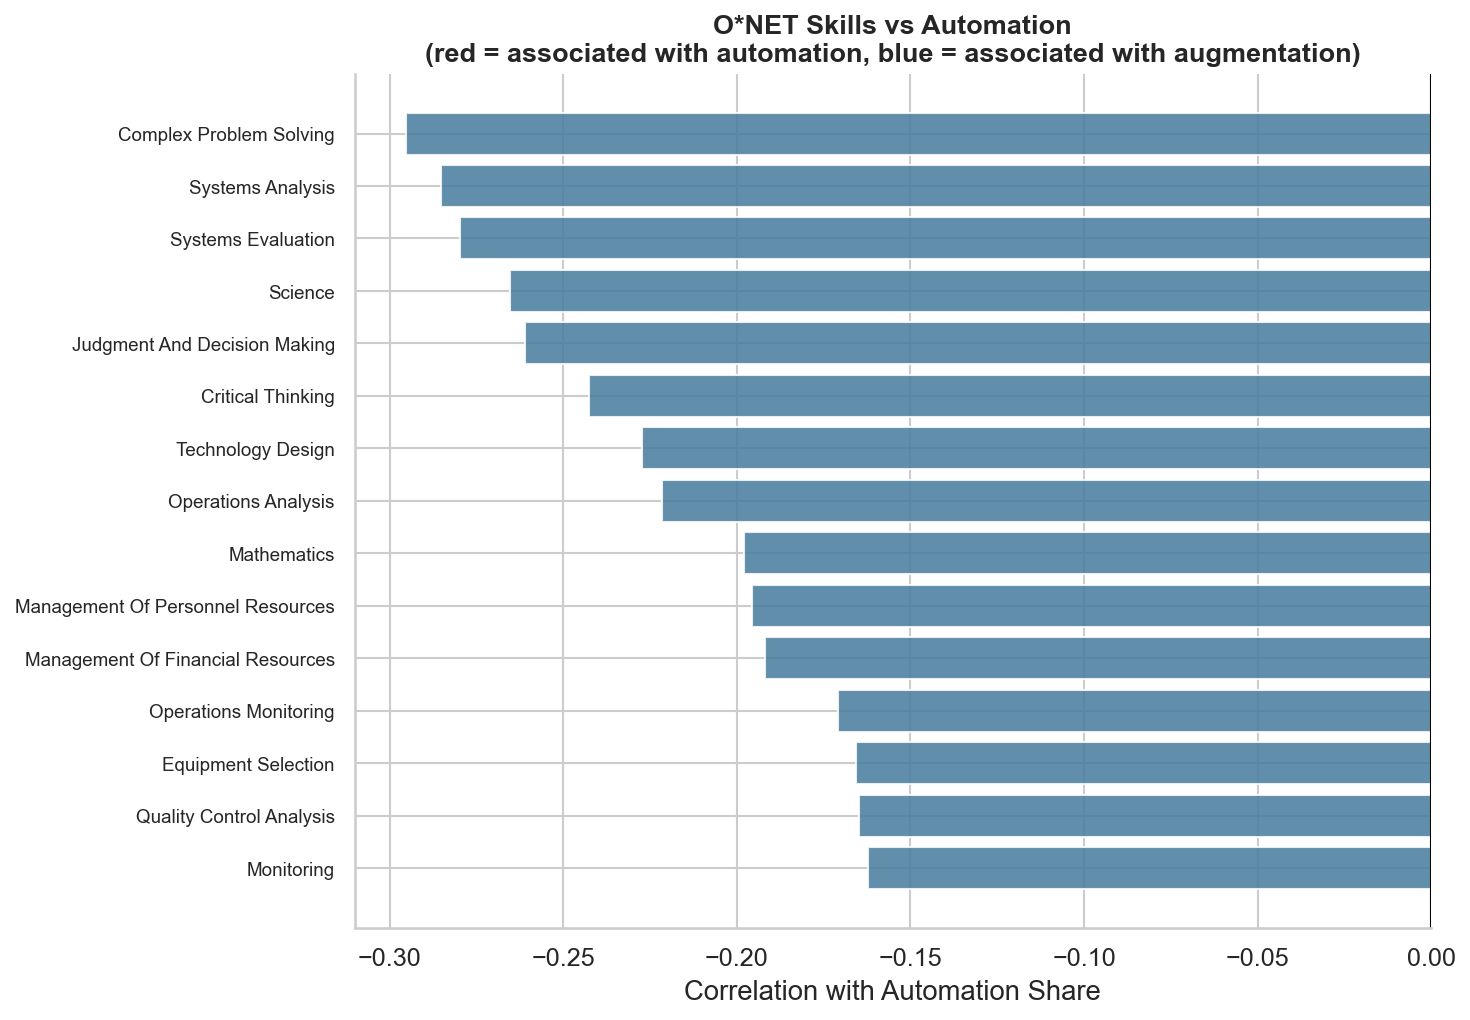

In [6]:
# Visualize top skill correlations
corrs_sorted = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)[:15]
names = [c[0] for c in corrs_sorted]
vals = [c[1] for c in corrs_sorted]

fig, ax = plt.subplots(figsize=(10, 7))
colors_list = [C['auto'] if v > 0 else C['aug'] for v in vals]
ax.barh(range(len(names)), vals, color=colors_list, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n.replace('_', ' ').title() for n in names], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
ax.set_xlabel('Correlation with Automation Share')
ax.set_title('O*NET Skills vs Automation\n(red = associated with automation, blue = associated with augmentation)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/13_skills_vs_automation.png', bbox_inches='tight')
plt.show()

## The Jagged Frontier: wage vs. automation

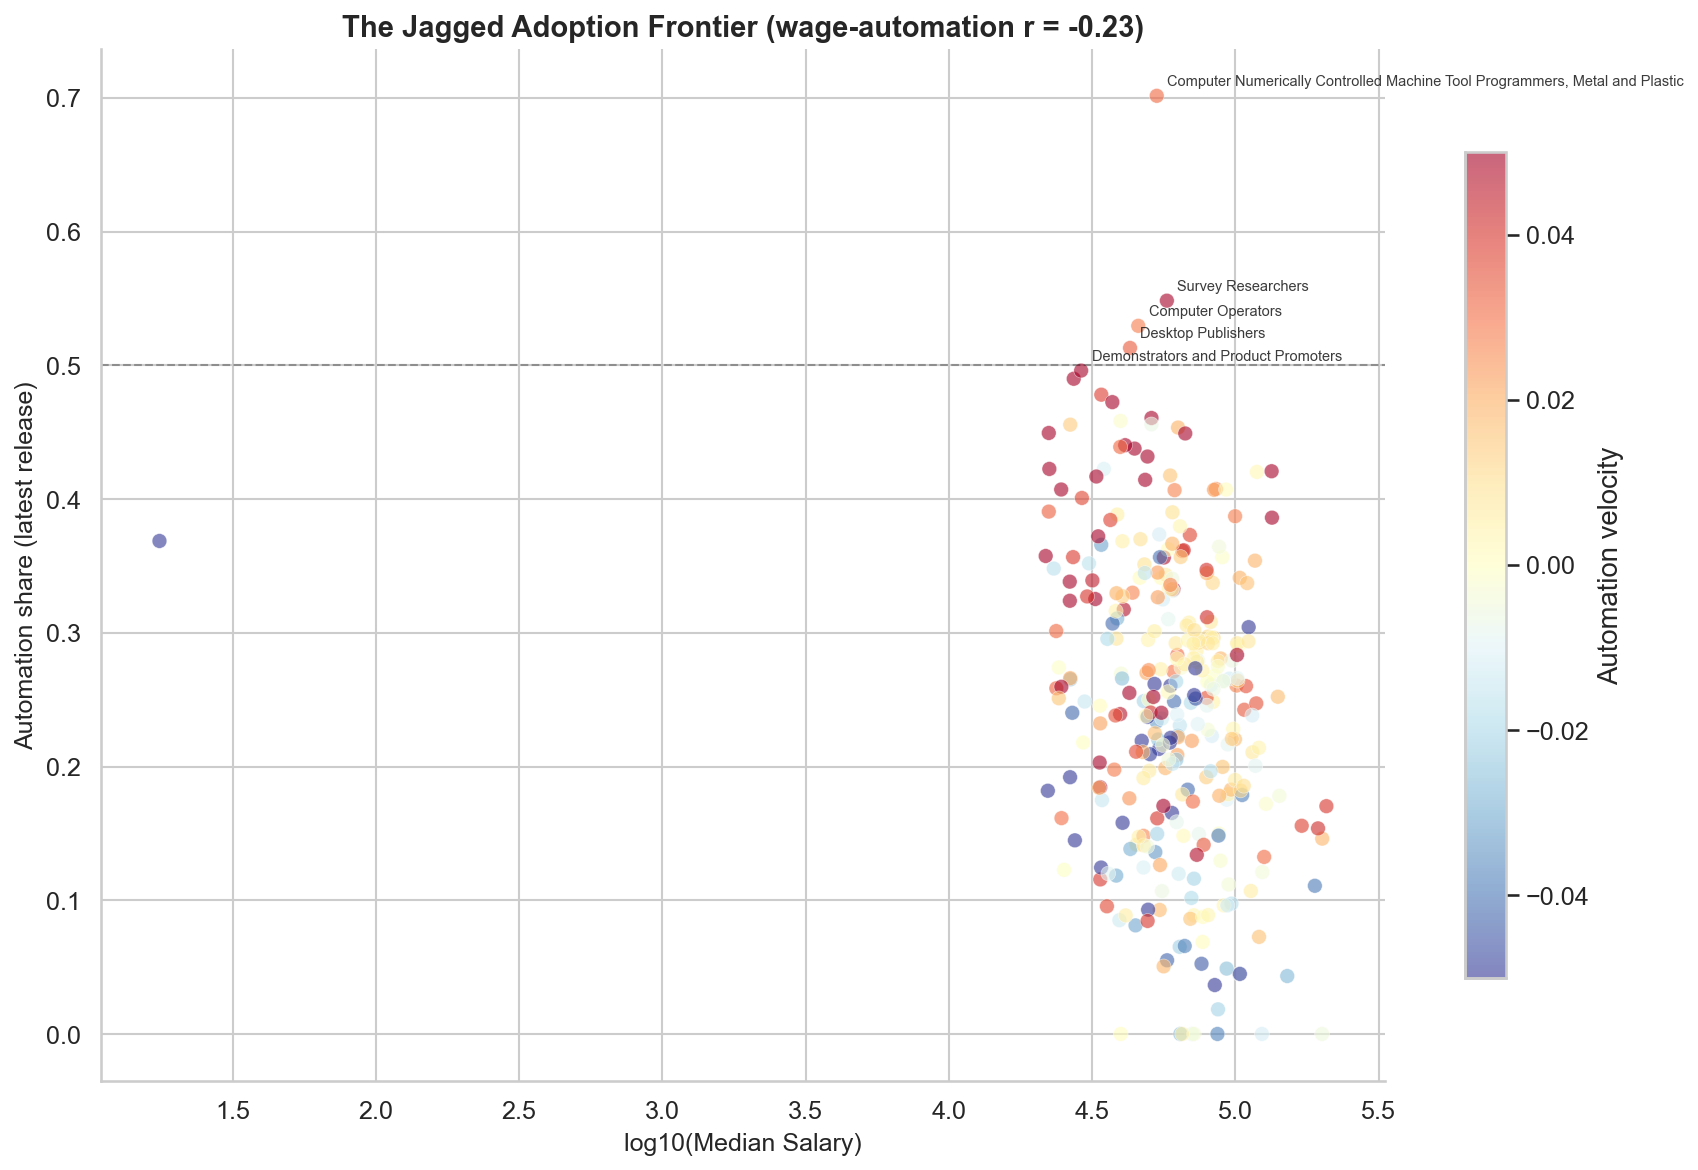

Wage explains only 5% of the variance in automation share.
The frontier is genuinely jagged.


In [7]:
plot_df = occ_features.dropna(subset=['mediansalary', 'latest_automation_share']).copy()
plot_df['log_salary'] = np.log10(plot_df['mediansalary'].clip(lower=1))

corr = plot_df['log_salary'].corr(plot_df['latest_automation_share'])

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    plot_df['log_salary'], plot_df['latest_automation_share'],
    c=plot_df.get('automation_velocity', 0).fillna(0),
    cmap='RdYlBu_r', s=50, alpha=0.6, edgecolors='white', linewidth=0.3,
    vmin=-0.05, vmax=0.05,
)
plt.colorbar(scatter, ax=ax, label='Automation velocity', shrink=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.3)

highlights = plot_df.nlargest(5, 'latest_automation_share')
for _, row in highlights.iterrows():
    ax.annotate(row['title'], (row['log_salary'], row['latest_automation_share']),
                fontsize=7, alpha=0.9, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('log10(Median Salary)', fontsize=12)
ax.set_ylabel('Automation share (latest release)', fontsize=12)
ax.set_title(f'The Jagged Adoption Frontier (wage-automation r = {corr:.2f})',
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/14_jagged_frontier.png', bbox_inches='tight')
plt.show()

print(f"Wage explains only {corr**2:.0%} of the variance in automation share.")
print(f"The frontier is genuinely jagged.")

---

**Key findings:**
1. **Tasks within the same occupation have wildly different AI autonomy** — the frontier is jagged at the task level
2. **Within-occupation heterogeneity** directly explains why occupation-level prediction fails
3. **O*NET skills predict automation resistance** — specific skill profiles distinguish automatable from augmentable occupations
4. **Wage explains almost nothing** — the frontier is genuinely jagged

**Next:** [05_synthesis.ipynb](05_synthesis.ipynb)